In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

attributes = [
    'Experience',
    'Performance',
    'Attendance',
    'Training'
]

data = [
    ['High',   'Excellent', 'Good', 'Yes', 'Yes'],
    ['High',   'Good',      'Good', 'Yes', 'Yes'],
    ['Low',    'Average',   'Poor', 'No',  'No'],
    ['High',   'Excellent', 'Good', 'No',  'Yes'],
    ['Medium', 'Average',   'Good', 'Yes', 'No'],
    ['High',   'Good',      'Good', 'No',  'Yes']
]

df = pd.DataFrame(
    data,
    columns=attributes + ['Promotion']
)

print("EMPLOYEE PROMOTION DATASET")
print(df)

X = df[attributes].values
y = df['Promotion'].values

n_attributes = len(attributes)

EMPLOYEE PROMOTION DATASET
  Experience Performance Attendance Training Promotion
0       High   Excellent       Good      Yes       Yes
1       High        Good       Good      Yes       Yes
2        Low     Average       Poor       No        No
3       High   Excellent       Good       No       Yes
4     Medium     Average       Good      Yes        No
5       High        Good       Good       No       Yes


In [2]:
def more_general(h1, h2):

    for x, y_value in zip(h1, h2):

        if x == '?':
            continue

        if x == '0':
            return False

        if x != y_value and y_value != '0':
            return False

    return True


def consistent(hypothesis, instance):

    for h, x in zip(hypothesis, instance):

        if h == '?':
            continue

        if h == '0':
            return False

        if h != x:
            return False

    return True


def min_generalization(hypothesis, instance):

    new_h = list(hypothesis)

    for i in range(len(hypothesis)):

        if hypothesis[i] == '0':
            new_h[i] = instance[i]

        elif hypothesis[i] != instance[i]:
            new_h[i] = '?'

    return [tuple(new_h)]


def min_specialization(hypothesis, domains, instance):

    results = []

    for i in range(len(hypothesis)):

        if hypothesis[i] == '?':

            for value in domains[i]:

                if value != instance[i]:

                    new_h = list(hypothesis)
                    new_h[i] = value

                    results.append(tuple(new_h))

    return results


def remove_more_general(hypotheses):

    return [
        h for h in hypotheses
        if not any(
            h != h2 and more_general(h2, h)
            for h2 in hypotheses
        )
    ]


def remove_less_general(hypotheses):

    return [
        h for h in hypotheses
        if not any(
            h != h2 and more_general(h, h2)
            for h2 in hypotheses
        )
    ]

In [3]:
def candidate_elimination(X, y):

    domains = [
        sorted(set(X[:, i]))
        for i in range(n_attributes)
    ]

    # Initialize Specific Boundary
    S = [
        tuple(['0'] * n_attributes)
    ]

    # Initialize General Boundary
    G = [
        tuple(['?'] * n_attributes)
    ]

    history_S = []
    history_G = []

    for i, instance in enumerate(X):

        instance = tuple(instance)

        print("\n================================")
        print("TRAINING EXAMPLE", i + 1)
        print("Instance:", instance)
        print("Output:", y[i])

        # Positive Example
        if y[i] == 'Yes':

            G = [
                g for g in G
                if consistent(g, instance)
            ]

            new_S = []

            for s in S:

                if consistent(s, instance):

                    new_S.append(s)

                else:

                    generalizations = min_generalization(
                        s,
                        instance
                    )

                    for h in generalizations:

                        if any(
                            more_general(g, h)
                            for g in G
                        ):

                            new_S.append(h)

            S = remove_more_general(
                list(set(new_S))
            )

        # Negative Example
        else:

            S = [
                s for s in S
                if not consistent(s, instance)
            ]

            new_G = []

            for g in G:

                if not consistent(g, instance):

                    new_G.append(g)

                else:

                    specializations = min_specialization(
                        g,
                        domains,
                        instance
                    )

                    for h in specializations:

                        if any(
                            more_general(h, s)
                            for s in S
                        ):

                            new_G.append(h)

            G = remove_less_general(
                list(set(new_G))
            )

        print("\nSpecific Boundary S:")

        for s in S:
            print(s)

        print("\nGeneral Boundary G:")

        for g in G:
            print(g)

        history_S.append(len(S))
        history_G.append(len(G))

    return S, G, history_S, history_G

In [4]:
S_final, G_final, history_S, history_G = candidate_elimination(
    X,
    y
)


TRAINING EXAMPLE 1
Instance: ('High', 'Excellent', 'Good', 'Yes')
Output: Yes

Specific Boundary S:
('High', 'Excellent', 'Good', 'Yes')

General Boundary G:
('?', '?', '?', '?')

TRAINING EXAMPLE 2
Instance: ('High', 'Good', 'Good', 'Yes')
Output: Yes

Specific Boundary S:
('High', '?', 'Good', 'Yes')

General Boundary G:
('?', '?', '?', '?')

TRAINING EXAMPLE 3
Instance: ('Low', 'Average', 'Poor', 'No')
Output: No

Specific Boundary S:
('High', '?', 'Good', 'Yes')

General Boundary G:
('High', '?', '?', '?')
('?', '?', '?', 'Yes')
('?', '?', 'Good', '?')

TRAINING EXAMPLE 4
Instance: ('High', 'Excellent', 'Good', 'No')
Output: Yes

Specific Boundary S:
('High', '?', 'Good', '?')

General Boundary G:
('High', '?', '?', '?')
('?', '?', 'Good', '?')

TRAINING EXAMPLE 5
Instance: ('Medium', 'Average', 'Good', 'Yes')
Output: No

Specific Boundary S:
('High', '?', 'Good', '?')

General Boundary G:
('High', '?', 'Good', '?')

TRAINING EXAMPLE 6
Instance: ('High', 'Good', 'Good', 'No')
Outp

In [5]:
print("\n================================")
print("FINAL SPECIFIC BOUNDARY (S)")
print("================================")

for s in S_final:
    print(s)

print("\n================================")
print("FINAL GENERAL BOUNDARY (G)")
print("================================")

for g in G_final:
    print(g)


FINAL SPECIFIC BOUNDARY (S)
('High', '?', 'Good', '?')

FINAL GENERAL BOUNDARY (G)
('High', '?', 'Good', '?')


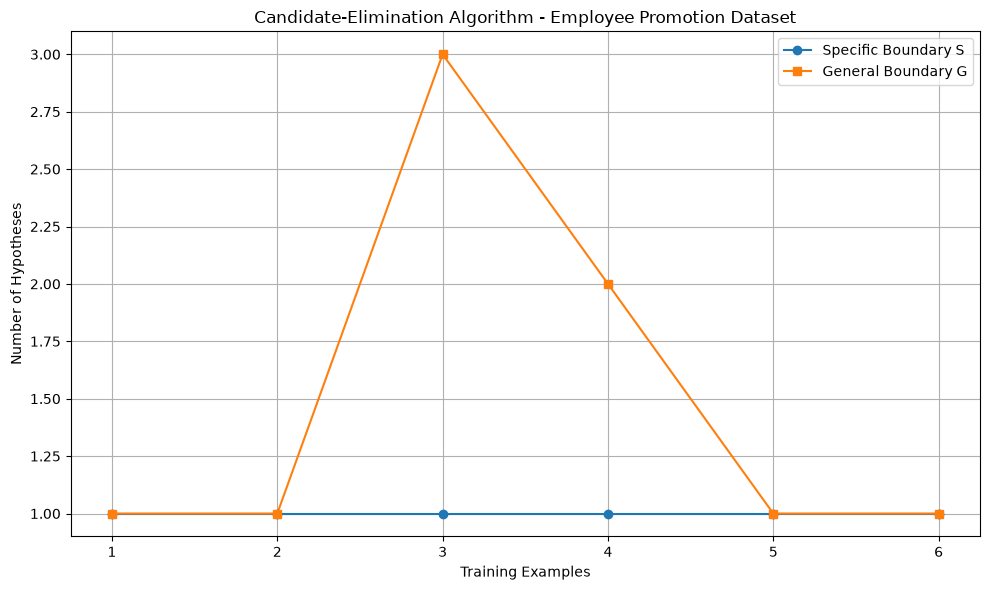

In [6]:
steps = range(
    1,
    len(history_S) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    steps,
    history_S,
    marker='o',
    label='Specific Boundary S'
)

plt.plot(
    steps,
    history_G,
    marker='s',
    label='General Boundary G'
)

plt.xlabel('Training Examples')
plt.ylabel('Number of Hypotheses')

plt.title(
    'Candidate-Elimination Algorithm - Employee Promotion Dataset'
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()